CLASSIFICAÇÃO COM RANDOM FOREST

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("/content/Global_Tech_Gadget_Consumption.csv")

print(df.head())


  Country  Year  Smartphone Sales (Millions)  Laptop Shipments (Millions)  \
0     USA  2015                       111.37                       123.63   
1     USA  2016                       224.65                        65.27   
2     USA  2017                       102.12                        26.75   
3     USA  2018                       148.10                       129.28   
4     USA  2019                        83.93                        97.81   

   Gaming Console Adoption (%)  Smartwatch Penetration (%)  \
0                        12.05                       14.49   
1                        12.92                        9.88   
2                        19.63                       17.35   
3                        26.44                       12.45   
4                        20.84                        6.18   

   Average Consumer Spending on Gadgets ($)  E-Waste Generated (Metric Tons)  \
0                                    311.21                           939.89   
1   

In [ ]:
 # 2. CRIAR VARIÁVEL CATEGÓRICA (ALVO)
# ---------------------------------------------------
# Transformar E-WASTE GENERATED em 3 faixas (baixo, médio, alto)
df["EWaste_Class"] = pd.qcut(
    df["E-Waste Generated (Metric Tons)"],
    q=3,
    labels=["Baixo", "Medio", "Alto"]
)

# Alvo
y = df["EWaste_Class"]

In [ ]:
# 3. defininir as variáveis explicativas (features)
# ---------------------------------------------------
# Usar apenas colunas numéricas
X = df.select_dtypes(include=[np.number])

# Remover a variável contínua original do alvo
X = X.drop(columns=["E-WASTE GENERATED"], errors="ignore")

print("\nVariáveis usadas como X:")
print(X.columns)



Variáveis usadas como X:
Index(['Year', 'Smartphone Sales (Millions)', 'Laptop Shipments (Millions)',
       'Gaming Console Adoption (%)', 'Smartwatch Penetration (%)',
       'Average Consumer Spending on Gadgets ($)',
       'E-Waste Generated (Metric Tons)', '5G Penetration Rate (%)'],
      dtype='object')


In [ ]:
# 4. SEPARAR TREINO/TESTE E NORMALIZAR
# ---------------------------------------------------
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Normalizar dados
scaler = StandardScaler()
X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)


In [ ]:
# 5. TREINAR MODELO RANDOM FOREST
# ---------------------------------------------------
modelo = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    max_features="sqrt",
    random_state=42
)

modelo.fit(X_treino_scaled, y_treino)

RandomForestClassifier(n_estimators=200, random_state=42)


Acurácia do modelo: 0.9697

Matriz de Confusão:
[[11  0  0]
 [ 0 11  0]
 [ 1  0 10]]

Relatório de Classificação:
              precision    recall  f1-score   support

        Alto       0.92      1.00      0.96        11
       Baixo       1.00      1.00      1.00        11
       Medio       1.00      0.91      0.95        11

    accuracy                           0.97        33
   macro avg       0.97      0.97      0.97        33
weighted avg       0.97      0.97      0.97        33



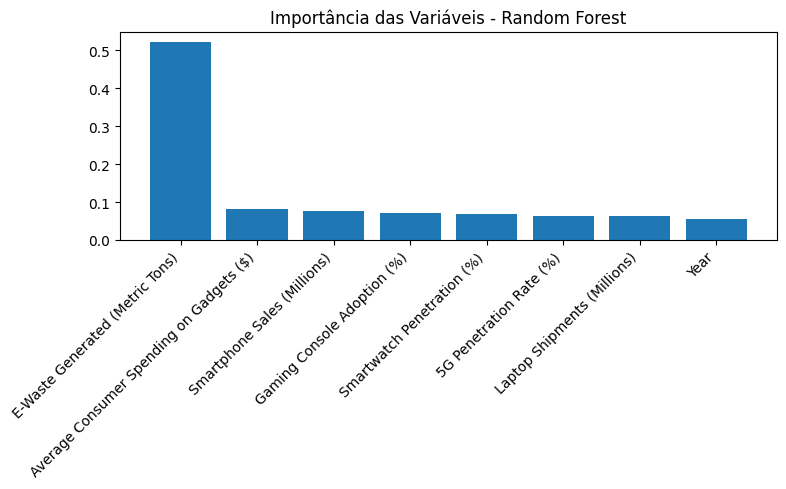

In [ ]:
# 6. AVALIAR O MODELO
# ---------------------------------------------------
y_pred = modelo.predict(X_teste_scaled)

# Acurácia
acc = accuracy_score(y_teste, y_pred)
print("\nAcurácia do modelo:", round(acc, 4))

# Matriz de confusão
cm = confusion_matrix(y_teste, y_pred)
print("\nMatriz de Confusão:")
print(cm)

# Relatório detalhado
print("\nRelatório de Classificação:")
print(classification_report(y_teste, y_pred))

# ---------------------------------------------------
# 7. IMPORTÂNCIA DAS VARIÁVEIS
# ---------------------------------------------------
importancias = modelo.feature_importances_
indices = np.argsort(importancias)[::-1]

plt.figure(figsize=(8,5))
plt.bar(range(len(indices)), importancias[indices])
plt.xticks(range(len(indices)), X.columns[indices], rotation=45, ha="right")
plt.title("Importância das Variáveis - Random Forest")
plt.tight_layout()
plt.show()


**Análise dos resultados obtidos**

O modelo apresentou uma acurácia muito alta porque houve data leakage. Isso significa que a variável usada para criar a classe alvo (o valor contínuo de “E-WASTE GENERATED”) permaneceu nas features durante o treinamento. Assim, o Random Forest não precisou aprender padrões reais: ele apenas usou diretamente o próprio valor de e-waste para reconstruir se o país era “baixo”, “médio” ou “alto”. Isso gera um desempenho artificialmente elevado, mas não representa a capacidade real de generalização do modelo.

Colunas do dataframe:
Index(['Country', 'Year', 'Smartphone Sales (Millions)',
       'Laptop Shipments (Millions)', 'Gaming Console Adoption (%)',
       'Smartwatch Penetration (%)',
       'Average Consumer Spending on Gadgets ($)',
       'E-Waste Generated (Metric Tons)', '5G Penetration Rate (%)'],
      dtype='object')

Features usadas como X (sem e-waste contínuo):
Index(['Year', 'Smartphone Sales (Millions)', 'Laptop Shipments (Millions)',
       'Gaming Console Adoption (%)', 'Smartwatch Penetration (%)',
       'Average Consumer Spending on Gadgets ($)', '5G Penetration Rate (%)'],
      dtype='object')

Acurácia (sem leakage): 0.3636

Matriz de Confusão:
[[6 3 2]
 [4 4 3]
 [3 6 2]]

Relatório de Classificação:
              precision    recall  f1-score   support

        Alto       0.46      0.55      0.50        11
       Baixo       0.31      0.36      0.33        11
       Medio       0.29      0.18      0.22        11

    accuracy                           0.36       

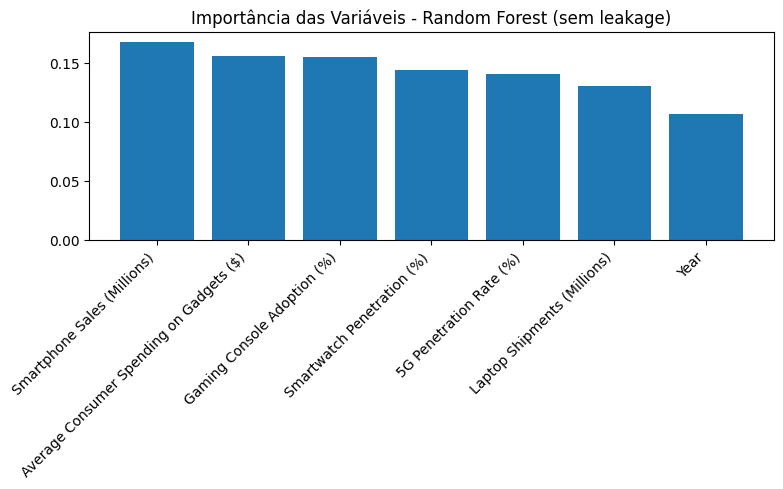

In [3]:
# ============================================
# RANDOM FOREST SEM LEAKAGE
# Base: Global_Tech_Gadget_Consumption.csv
# Target: categorias de E-Waste
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ---------------------------------------------------
# 1. CARREGAR A BASE
# ---------------------------------------------------
df = pd.read_csv("/content/Global_Tech_Gadget_Consumption.csv")

# >>> AJUSTE AQUI SE O NOME DA COLUNA FOR DIFERENTE <<<
col_ewaste = "E-Waste Generated (Metric Tons)"

print("Colunas do dataframe:")
print(df.columns)

# ---------------------------------------------------
# 2. CRIAR A VARIÁVEL CATEGÓRICA ALVO (SEM USAR COMO FEATURE)
# ---------------------------------------------------
df["EWaste_Class"] = pd.qcut(
    df[col_ewaste],
    q=3,
    labels=["Baixo", "Medio", "Alto"]
)

y = df["EWaste_Class"]

# ---------------------------------------------------
# 3. DEFINIR FEATURES SEM A COLUNA DE E-WASTE
# ---------------------------------------------------
# Pega apenas colunas numéricas
X = df.select_dtypes(include=[np.number])

# Remove a coluna contínua de e-waste (para evitar leakage)
X = X.drop(columns=[col_ewaste], errors="ignore")

print("\nFeatures usadas como X (sem e-waste contínuo):")
print(X.columns)

# ---------------------------------------------------
# 4. TREINO / TESTE + NORMALIZAÇÃO
# ---------------------------------------------------
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)

# ---------------------------------------------------
# 5. TREINAR RANDOM FOREST
# ---------------------------------------------------
modelo = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    max_features="sqrt",
    random_state=42
)

modelo.fit(X_treino_scaled, y_treino)

# ---------------------------------------------------
# 6. AVALIAR O MODELO
# ---------------------------------------------------
y_pred = modelo.predict(X_teste_scaled)

acc = accuracy_score(y_teste, y_pred)
cm = confusion_matrix(y_teste, y_pred)

print("\nAcurácia (sem leakage):", round(acc, 4))
print("\nMatriz de Confusão:")
print(cm)

print("\nRelatório de Classificação:")
print(classification_report(y_teste, y_pred))

# ---------------------------------------------------
# 7. IMPORTÂNCIA DAS VARIÁVEIS (AGORA SEM E-WASTE)
# ---------------------------------------------------
importancias = modelo.feature_importances_
indices = np.argsort(importancias)[::-1]

plt.figure(figsize=(8,5))
plt.bar(range(len(indices)), importancias[indices])
plt.xticks(range(len(indices)), X.columns[indices], rotation=45, ha="right")
plt.title("Importância das Variáveis - Random Forest (sem leakage)")
plt.tight_layout()
plt.show()

Após a remoção da variável contínua “E-Waste Generated (Metric Tons)” das features, eliminando o problema de data leakage, o desempenho do modelo diminuiu significativamente, resultando em uma acurácia de aproximadamente 0,36. Esse valor indica que o modelo acertou cerca de 36% das predições. Embora mais baixo do que o observado anteriormente, esse desempenho é coerente com a configuração correta do problema, já que agora o modelo utiliza apenas variáveis indiretas para prever as categorias.

A matriz de confusão obtida demonstra uma distribuição equilibrada de erros entre as três classes. Não há uma classe claramente dominante ou facilmente distinguível, e as previsões apresentam sobreposição entre os grupos Baixo, Médio e Alto. Isso indica que as variáveis disponíveis na base não fornecem separações nítidas ou padrões fortes o suficiente para diferenciar adequadamente os três níveis de e-waste.

As métricas individuais (precision, recall e f1-score) reforçam essa interpretação, apresentando valores entre 0,18 e 0,55. Tais valores revelam dificuldade do modelo em identificar corretamente cada classe, sugerindo que as variáveis explicativas possuem relação fraca com a classificação categorizada do e-waste.

O gráfico de importância das variáveis mostra que nenhuma feature possui peso dominante no processo de decisão do modelo. As importâncias são relativamente próximas entre si, o que é esperado em situações em que não existe uma variável fortemente correlacionada com o alvo. Assim, o modelo distribui seu poder preditivo entre várias features que, individualmente, contribuem pouco para a diferenciação das classes.

Em conclusão, o Random Forest sem leakage evidencia que os níveis categorizados de e-waste não são fortemente explicados pelas variáveis tecnológicas presentes na base. A acurácia em torno de 36% representa um resultado realista, que reflete a inexistência de padrões suficientemente robustos para predizer a categoria de e-waste sem utilizar o próprio valor contínuo originalmente responsável por defini-la.